<a href="https://colab.research.google.com/github/harmanbajwa2954/Machine-Learning-Notebooks/blob/main/Type_of_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Type of Brain Tumor Detection using MRI images**

## Importing Libraries and Tools

In [4]:
!git clone https://github.com/harmanbajwa2954/MRI_Brain_Tumor_Detection.git

Cloning into 'MRI_Brain_Tumor_Detection'...
remote: Enumerating objects: 7280, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 7280 (delta 22), reused 35 (delta 3), pack-reused 7211 (from 3)
Receiving objects: 100% (7280/7280), 155.66 MiB | 27.59 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (7501/7501), done.
Filtering content: 100% (2/2), 244.47 MiB | 5.64 MiB/s, done.


In [ ]:
!pip install tensorflow


In [39]:

import os #for directory and file operations
import numpy as np
import random
from PIL import Image, ImageEnhance # Pillow library used to work with images
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

#keras
from keras.layers import (Input, GlobalAveragePooling2D, Dense, Flatten,
                                      Dropout, BatchNormalization)
from keras.models import Sequential  #for building the model
from keras.preprocessing.image import load_img
from keras.optimizers import Adam    #for optimization
from keras.applications import VGG16
from keras.callbacks import ReduceLROnPlateau

from sklearn.utils import shuffle # for shuffling the data

In [ ]:
!python --version

Python 3.12.13


## Load Datasets

In [33]:
# Directories for training and testing data
train_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Training/'
test_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/'

#laod and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

## Data Visualization

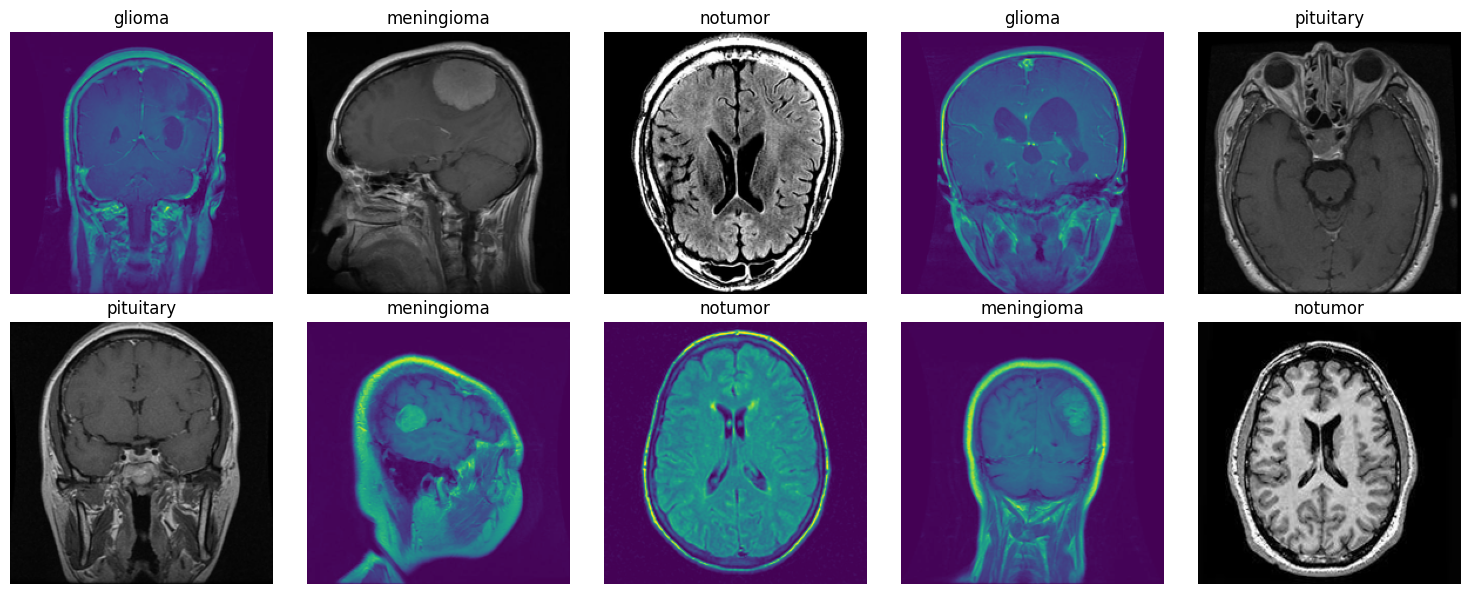

In [34]:
#selecting random incies for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((224,224))

  #Display images inside the loop
  axes[i].imshow(img)
  axes[i].set_title(train_labels[idx]) # Add title with label
  axes[i].axis("off")

plt.tight_layout()
plt.show()

## Image Preprocessing (Helper Functions)

In [35]:
from numpy._core.defchararray import encode
#image augmentation fucntion
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0
  return image

#Load images and apply augmentation
def open_images(path):
  image = []
  for img_path in path:
    img = load_img(img_path, target_size=(224,224))
    img = augment_image(img)
    image.append(img)

  return np.array(image)


#Encoder labels : converts label names to integers
def encode_label(labels_to_encode):
  unique_labels = sorted(os.listdir(train_dir)) # Ensure consistent order
  encoded_labels = [unique_labels.index(label) for label in labels_to_encode]
  return np.array(encoded_labels) # Return as a numpy array

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=15):
  for _ in range(epochs):
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_images(batch_paths)
      batch_labels = labels[i:i+batch_size]
      batch_labels = encode_label(batch_labels)
      yield batch_images, batch_labels

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

## **MODEL**

Here for this project we are going to use **Resnet50** for Transfer Learning.

> **Resnet50** is a pre-trained convolutional neural network (CNN) for image classification.

In [47]:
# Model architecture
IMAGE_SIZE = 224
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 15

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps,callbacks=[lr_scheduler])

Class weights: {'glioma': np.float64(1.0), 'meningioma': np.float64(1.0), 'notumor': np.float64(1.0), 'pituitary': np.float64(1.0)}


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,772 (57.65 MB)

 Trainable params: 13,375,748 (51.02 MB)

 Non-trainable params: 1,737,024 (6.63 MB)


── Phase 1: Training classification head ──
Epoch 1/8
  1/280 ━━━━━━━━━━━━━━━━━━━━ 2:08:18 28s/step - loss: 1.7426 - sparse_categorical_accuracy: 0.3000

KeyboardInterrupt: 

## Train and Vals

<function matplotlib.pyplot.show(close=None, block=None)>

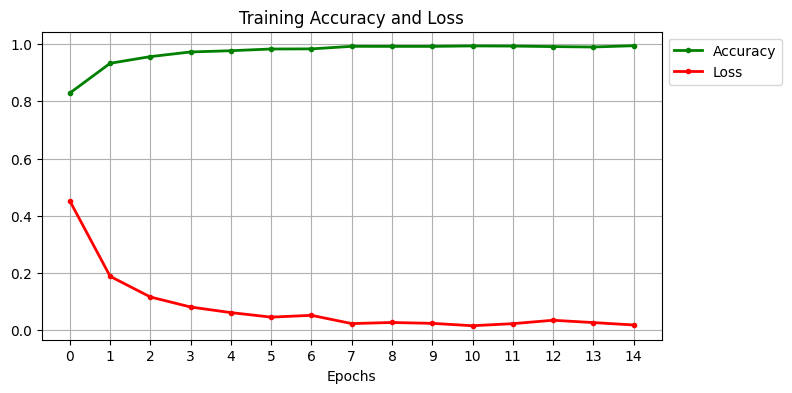

In [ ]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2, label='Training Accuracy')
plt.plot(history.history['loss'],'.r-', linewidth=2)
plt.title('Training Accuracy and Loss')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show

### Classification Report

In [ ]:
test_images = open_images(test_paths)
test_label_encoded = encode_label(test_labels)

y_pred = model.predict(test_images)

print('Classification Report:')
print(classification_report(test_label_encoded, np.argmax(y_pred, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       400
           1       0.92      0.92      0.92       400
           2       0.91      1.00      0.95       400
           3       0.93      0.99      0.96       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



### Confusion Matrix

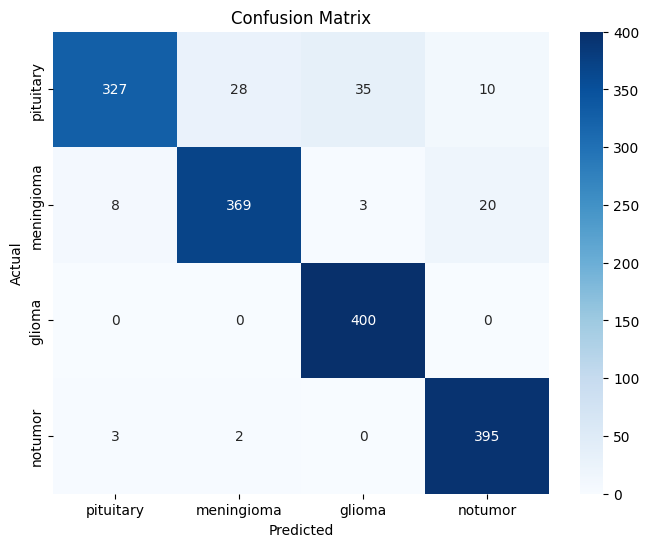

In [ ]:
conf_matrix = confusion_matrix(test_label_encoded, np.argmax(y_pred, axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC and AUC curve

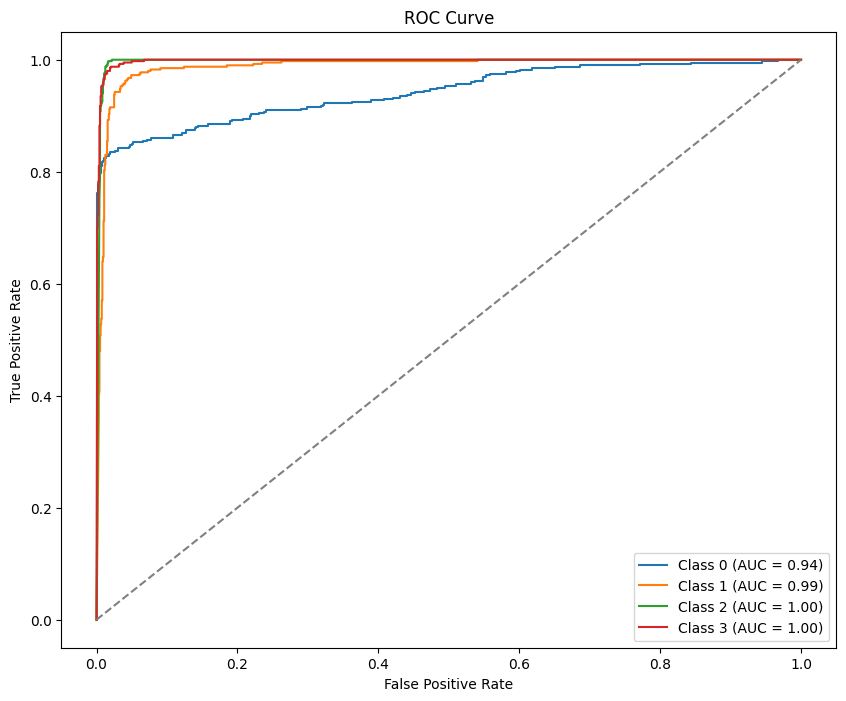

In [ ]:
#4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_label_encoded, classes=np.arange(len(os.listdir(train_dir))))
y_pred_bin =y_pred  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i],y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Saving the model

In [ ]:
# model.save('brain_tumor_model.h5')
model.save('brain_tumortype_model.keras')


### Loading the model

In [1]:
from keras.models import load_model
bt_model = load_model('brain_tumortype_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
[[0. 1. 0. 0.]]
Predicted class index: 1
Predicted tumor name: meningioma


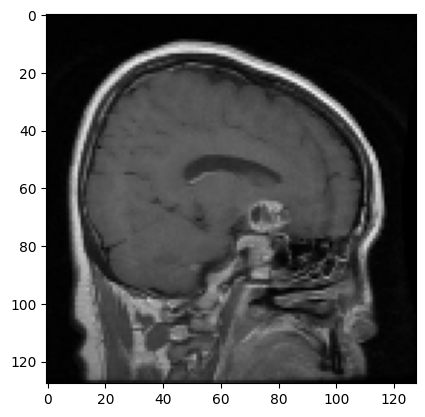

In [32]:
test_img = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/pituitary/Te-pi_239.jpg'
img = load_img(test_img, target_size=(128,128))

pred = bt_model.predict(np.expand_dims(img, axis=0))
print(pred)
predicted_class_index = np.argmax(pred)
class_labels = ['glioma', 'meningioma', 'notumor', 'pitutary']
print(f"Predicted class index: {predicted_class_index}")
print(f"Predicted tumor name: {class_labels[predicted_class_index]}")
plt.imshow(img)

## Implementing Explainable AI

---



In [12]:
!pip install opencv-python-headless

In [13]:
for i, layer in enumerate(bt_model.layers):
    print(i, type(layer).__name__, layer.name,
          f"→ output: {layer.output_shape}" if hasattr(layer, 'output_shape') else "")

0 Functional vgg16 → output: (None, 4, 4, 512)
1 Flatten flatten 
2 Dropout dropout 
3 Dense dense 
4 Dropout dropout_1 
5 Dense dense_1 


In [14]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img, img_to_array

IMAGE_SIZE = 128
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']


def _get_conv_extractor(model):
    """Returns a Functional model: VGG16 input → block5_conv3 output only."""
    vgg16     = model.get_layer('vgg16')
    last_conv = vgg16.get_layer('block5_conv3')
    return tf.keras.Model(inputs=vgg16.input, outputs=last_conv.output), vgg16


# ─── EigenCAM ─────────────────────────────────────────────────────────────────
def compute_eigencam(model, img_array):
    img_tensor = tf.cast(img_array, tf.float32)

    # ✅ Use model() directly for predictions
    preds      = model(img_tensor, training=False)
    class_idx  = int(tf.argmax(preds[0]).numpy())
    confidence = float(tf.reduce_max(preds).numpy())

    extractor, _ = _get_conv_extractor(model)
    conv_out      = extractor(img_tensor)             # (1, 14, 14, 512)

    acts     = conv_out[0].numpy()                    # (14, 14, 512)
    h, w, c  = acts.shape
    reshaped = acts.reshape(h * w, c)
    reshaped -= reshaped.mean(axis=0)

    _, _, Vt        = np.linalg.svd(reshaped, full_matrices=False)
    heatmap         = reshaped @ Vt[0]                # (h*w,)
    heatmap         = heatmap.reshape(h, w)
    heatmap         = np.maximum(heatmap, 0)
    heatmap         = heatmap / (heatmap.max() + 1e-8)

    return heatmap, class_idx, confidence


# ─── Overlay ──────────────────────────────────────────────────────────────────
def overlay_heatmap(heatmap, original_img, alpha=0.45):
    h, w    = original_img.shape[:2]
    resized = cv2.resize(heatmap, (w, h))
    colored = cv2.applyColorMap(np.uint8(255 * resized), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(original_img, 1 - alpha, colored, alpha, 0)

In [15]:
def detect_and_display_xai(image_path, model, method='gradcam', alpha=0.45):
    """
    Args:
        image_path : str path to MRI image
        model      : trained Keras model (bt_model)
        method     : 'gradcam' or 'eigencam'
        alpha      : heatmap opacity (0.0–1.0)
    """
    try:
        img        = load_img(image_path, target_size=(128, 128))
        img_array  = img_to_array(img)                   # (224, 224, 3)
        img_input  = np.expand_dims(img_array, axis=0)   # (1, 224, 224, 3)
        orig_uint8 = img_array.astype(np.uint8)

        method = method.lower()
        if method == 'gradcam':
            heatmap, class_idx, confidence = compute_gradcam(model, img_input)
            method_label = 'Grad-CAM'
        elif method == 'eigencam':
            heatmap, class_idx, confidence = compute_eigencam(model, img_input)
            method_label = 'EigenCAM'
        else:
            raise ValueError("method must be 'gradcam' or 'eigencam'")

        label       = class_labels[class_idx]
        result_text = 'No Tumor Detected' if label == 'notumor' else f'Tumor: {label.capitalize()}'
        superimposed = overlay_heatmap(heatmap, orig_uint8, alpha=alpha)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(
            f'{method_label}  |  {result_text}  |  Confidence: {confidence*100:.1f}%',
            fontsize=13, fontweight='bold'
        )
        axes[0].imshow(orig_uint8);       axes[0].set_title('Original MRI');            axes[0].axis('off')
        axes[1].imshow(cv2.resize(heatmap, (IMAGE_SIZE, IMAGE_SIZE)), cmap='jet')
        axes[1].set_title(f'{method_label} Heatmap');  axes[1].axis('off')
        axes[2].imshow(superimposed);     axes[2].set_title('Overlay');                 axes[2].axis('off')

        sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
        plt.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04, label='Activation intensity')
        plt.tight_layout()
        plt.show()

        print(f"  Predicted : {label}  |  Confidence: {confidence*100:.2f}%  |  Method: {method_label}")

    except Exception as e:
        import traceback
        print(f'Error: {e}')
        traceback.print_exc()   # full traceback so errors are easier to debug

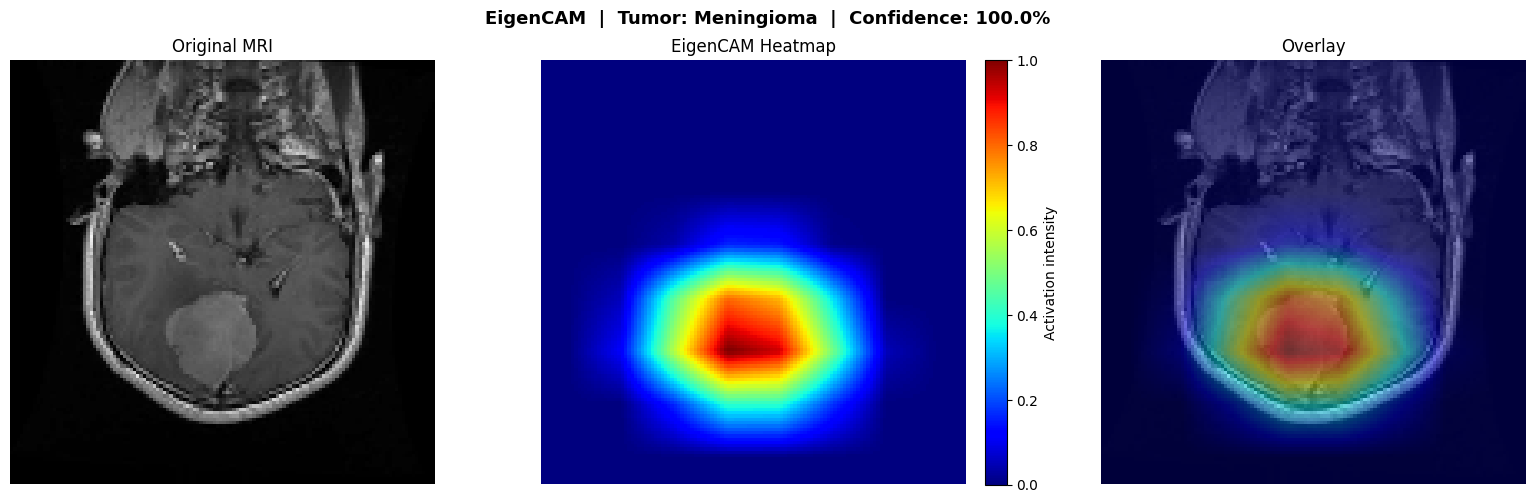

  Predicted : meningioma  |  Confidence: 100.00%  |  Method: EigenCAM


In [25]:
# ── Test a single image with both methods side by side ──
img_path = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/meningioma/Te-aug-me_69.jpg'

# Run EigenCAM on the same image
detect_and_display_xai(img_path, bt_model, method='eigencam')